#### K-Nearest Neighbors

***Predictors***:

**Spatial Factors:**
- *cell_code*: spatial element, identifying the block that generated the trip. The blocks are generated using a grid approach, with precision equal to either 5 or 6: the higher, the smaller the cells. 
- *POIs:* number of POIs nearby, divided and counted according to their type (category of belonging): *leisure, public_services, building, education, food, transport, finantial, healthcare, office, shop, tourism*.


**Temporal Factors:**

- *hour*: variable indicating the time of the day. Hour are groupped into equally sized intervals according to the specified aggregation frequency.
- *month*: integer representing the month.
- *day_of_month*: number of the day of the month.
- *day_of_week* number of the day of the week (0-6).
- *is_weekend*: boolean variable, either True (for Saturdays and Sundays) or False (otherwise).
- *holiday*: boolean variable, True if the trips happenend during a holiday recognized in Italy, False otherwise.


**Others:**


**Weather related factors:**
- *totalSnow_cm*: centimeter of snow.
- *windspeedKmph*: windspeed in km/h.
- *tempC*: temperature in Celsius.
- *visibility*: degree of visibility.
- *precipMM*: millimiter of rain.

**Multimodality factor:**
- *count_bus_multimodality*: median number of busses nearby for the same route.

In [1]:
import pandas as pd
import numpy as np
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# my functions
from prepare_data import create_dataframe
from knn import *

In [2]:
df = create_dataframe(aggr_freq='8H', precision=5)

In [3]:
df.trips_count.mean(), df.trips_count.median(), df.trips_count.min(), df.trips_count.max()

(9.014618011096884, 1.0, -1.0, 134.0)

In [4]:
df[df['trips_count']!=0].groupby(['cell_code']).size().reset_index().rename(columns={0:'count'})

,cell_code,count
0,u0pvu,451
1,u0pvv,1273
2,u0pyh,1366
3,u0pyj,1435
4,u0pyk,284
5,u0pym,311


In [5]:
# shuffle the data 
df = shuffle(df, random_state=42)
# one-hot encoding
df = pd.get_dummies(df)
# split test and training set
X_train, X_test, y_train, y_test = train_test_split(df[df.columns.drop('trips_count')], df[['trips_count']], test_size=0.25, random_state=42)

# normalize features based on TRAIN mean and std of the respective column
for col in X_train.columns.drop(list(df.filter(regex='cell_code'))):
    avg = X_train[col].mean()
    std = X_train[col].std()
    X_train[col] = (X_train[col] - avg) / std
    X_test[col] = (X_test[col] - avg) / std

# normalize target based on TRAIN mean and std
trips_cnt_avg = y_train.mean()
trips_cnt_std = y_train.std()
y_train = (y_train - trips_cnt_avg) / trips_cnt_std
y_test = (y_test - trips_cnt_avg) / trips_cnt_std

In [6]:
# model
model = KNeighborsRegressor(n_neighbors=25, weights='distance').fit(X_train, y_train) # weights='distance' -> closer neighbors, greater influence

In [7]:
# predict
predictions = model.predict(X_test)

In [8]:
# on norm data
print('MAE:',mean_absolute_error(y_test, predictions), 
    '\nMSE:', mean_squared_error(y_test, predictions), 
    '\nMAPE:', mean_absolute_percentage_error(y_test, predictions),
    '\nR-Squared:', r2_score(y_test, predictions))

MAE: 0.23831344050722386 
MSE: 0.2303043163055551 
MAPE: 16544498397403.678 
R-Squared: 0.7638563540050367


The R^2 is quite good (the more the value is similar to 1 the better); the value of 0.763 means that approximately 76.3% of the total variance is explained by the model. However, R^2 alone is not a metric for evaluating a model as it may mislead the evaluation of the performance and lead to prefer a overfitting model. Nevertherless, the error is also quite low. Performances may be improved selecting the optmimal k.

#### Optimize k

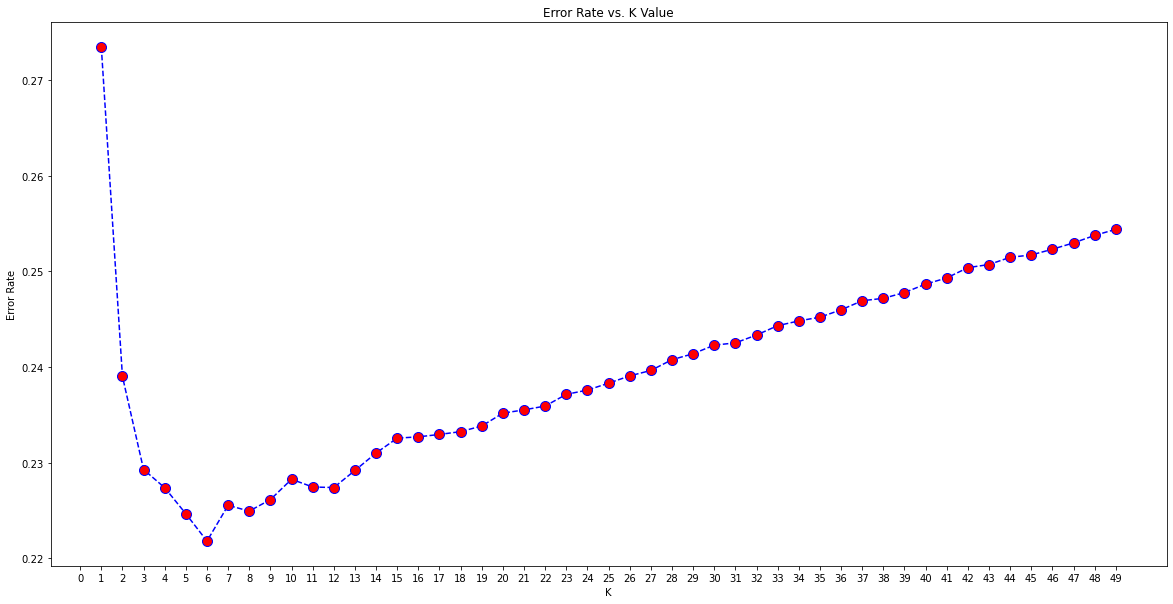

Minimum error: 0.22180096257042292 at K = 6


In [9]:
opt_k = find_optimal_k(X_train, y_train, X_test, y_test)

In [10]:
model = KNeighborsRegressor(n_neighbors=opt_k, weights='distance').fit(X_train, y_train) 
predictions = model.predict(X_test) 
metrics_8h_prec5 = evaluation_metrics(y_test, predictions) # norm data

MAE: 0.22180096257042292 
MSE: 0.22697662518558934 
MAPE: 17590367040331.275 
R-Squared: 0.7672684182095616


In [15]:
# de-norm
predictions = (predictions * trips_cnt_std[0])+trips_cnt_avg[0]
y_test = (y_test * trips_cnt_std)+trips_cnt_avg
# error on original data
metrics_8h_prec5 = evaluation_metrics(y_test, predictions)

MAE: 4.158314196190823 
MSE: 79.7790541479369 
MAPE: 1754253264807879.5 
R-Squared: 0.7672684182095617


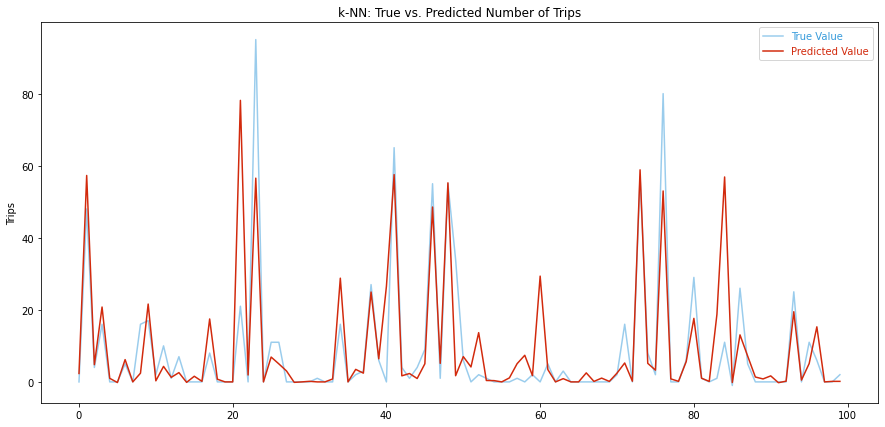

In [17]:
pred_vs_true(y_test, predictions)

#### Try different spatio-temporal aggregations

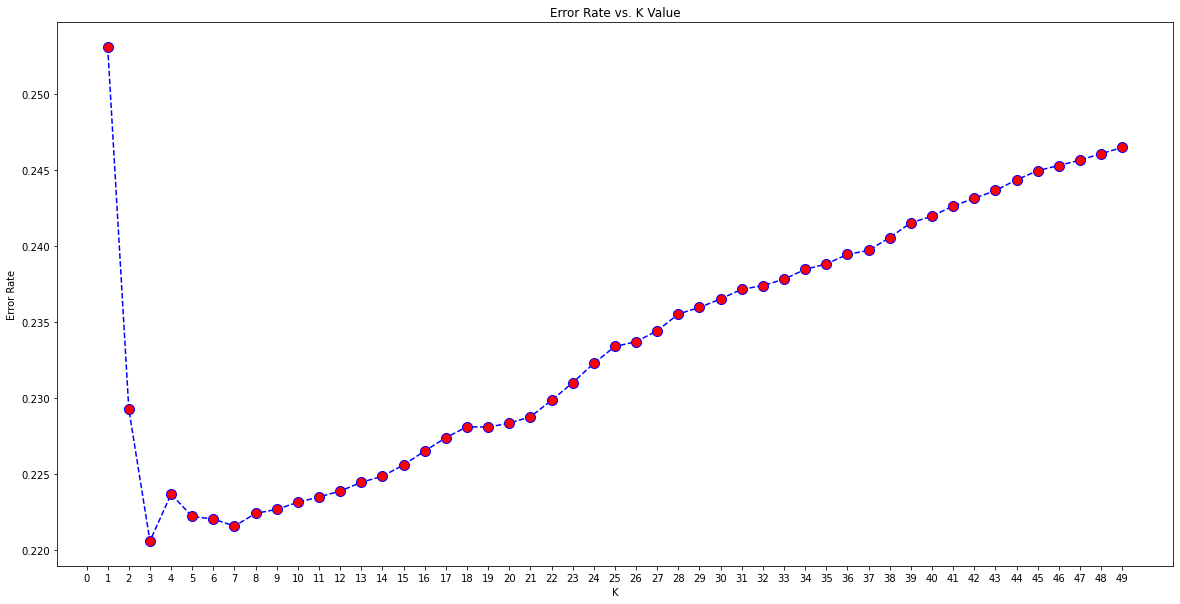

Minimum error: 0.22056778579301684 at K = 3


In [18]:
model, X_train, X_test, y_train, y_test, trips_cnt_avg, trips_cnt_std, predictions = train_knn(aggr_freq='4H', precision=5)

In [19]:
model

KNeighborsRegressor(n_neighbors=3, weights='distance')

In [20]:
metrics_4h_prec5 = evaluation_metrics(y_test, predictions)

MAE: 0.22056778579301684 
MSE: 0.26484429658302705 
MAPE: 0.7286379402359063 
R-Squared: 0.7255039016970753


In [21]:
# denormalize (for plotting real values)
y_test_orig = (y_test * trips_cnt_std) + trips_cnt_avg
predictions = (predictions.flatten() * trips_cnt_std[0]) + trips_cnt_avg[0]

In [22]:
metrics_4h_prec5 = evaluation_metrics(y_test_orig, predictions)

MAE: 2.2797418745469558 
MSE: 28.29292255820667 
MAPE: 749956347343065.5 
R-Squared: 0.7255039016970755


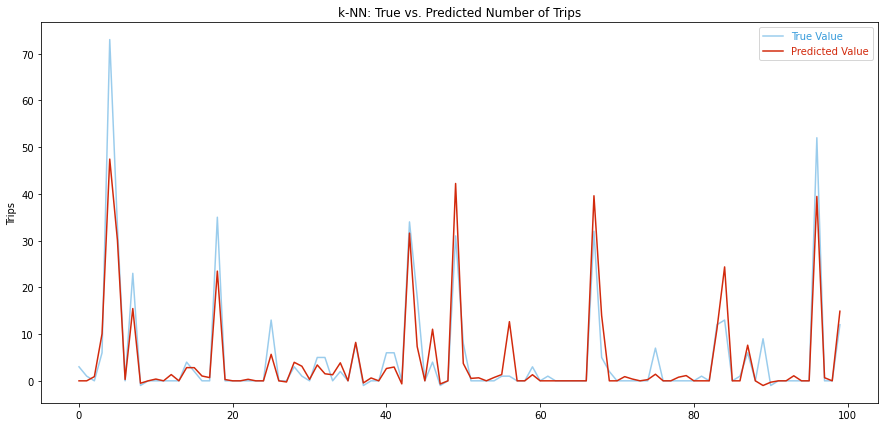

In [23]:
pred_vs_true(y_test_orig, predictions)

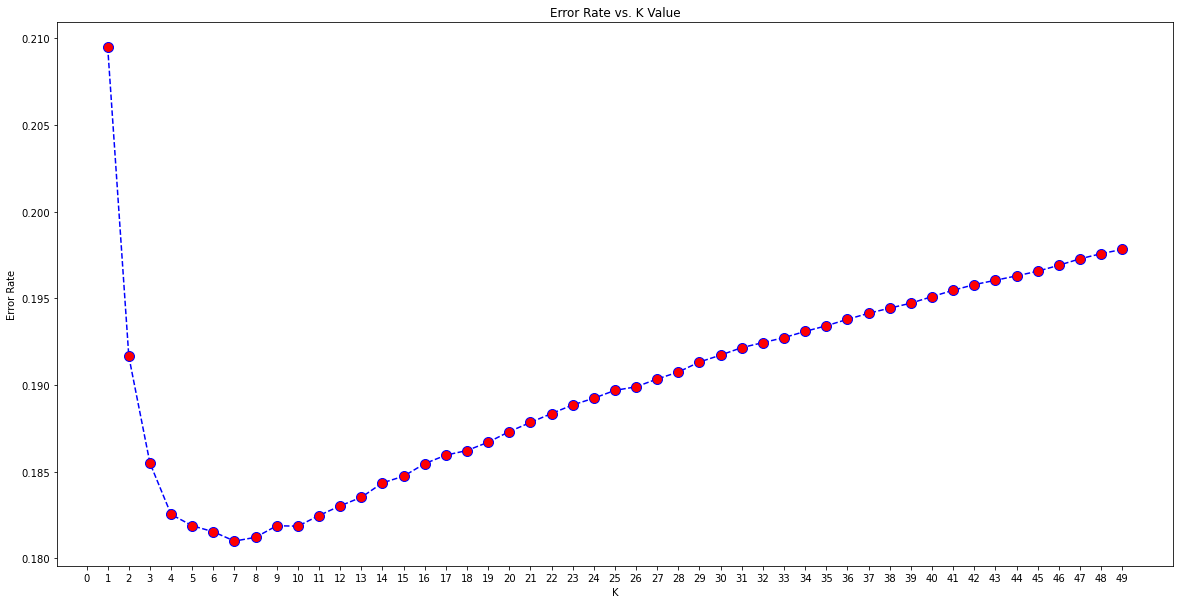

Minimum error: 0.18098712479124945 at K = 7
MAE: 0.5196691863001711 
MSE: 1.6479345355572406 
MAPE: 257214030942534.3 
R-Squared: 0.8076032344203459


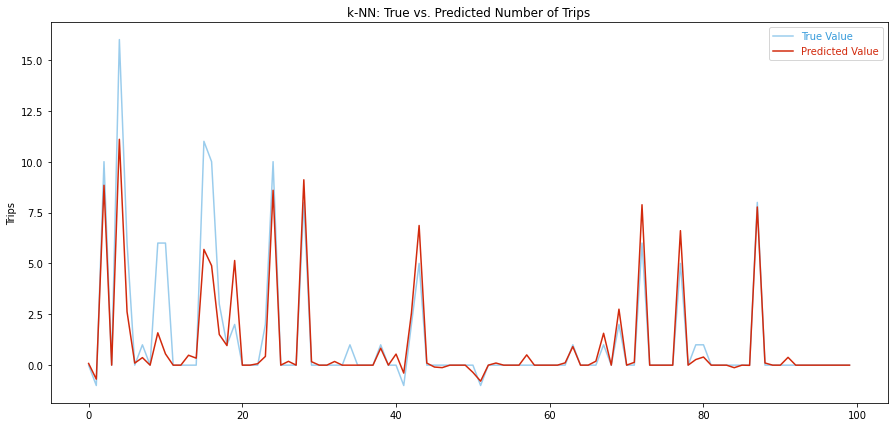

In [24]:
# H - prec=5
aggr_freq='H'
prec=5
# train 
model, X_train, X_test, y_train, y_test, trips_cnt_avg, trips_cnt_std, predictions = train_knn(aggr_freq=aggr_freq, precision=prec)
# evaluate
# metrics_h_prec5 = evaluation_metrics(y_test, predictions)
# denormalize (for plotting real values)
y_test_orig = (y_test * trips_cnt_std) + trips_cnt_avg
predictions = (predictions.flatten() * trips_cnt_std[0]) + trips_cnt_avg[0]
# evaluate on original data
metrics_h_prec5 = evaluation_metrics(y_test_orig, predictions)
# plot 
pred_vs_true(y_test_orig, predictions)

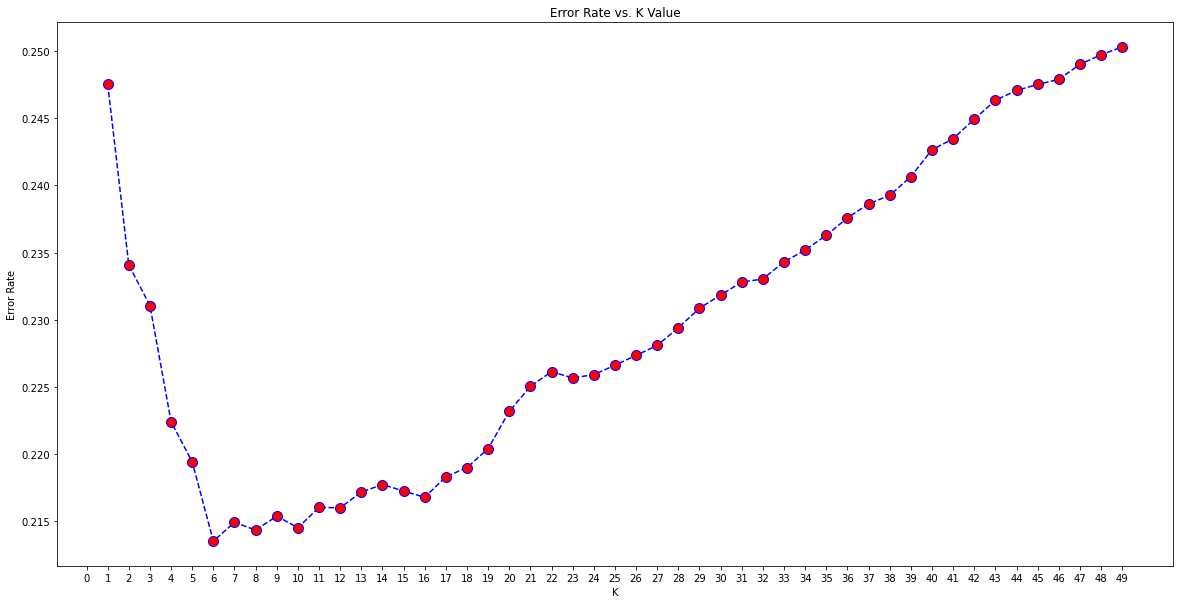

Minimum error: 0.21350822378937184 at K = 6
MAE: 9.978652371945431 
MSE: 391.91791399957566 
MAPE: 4297735785594635.0 
R-Squared: 0.8376003535108321


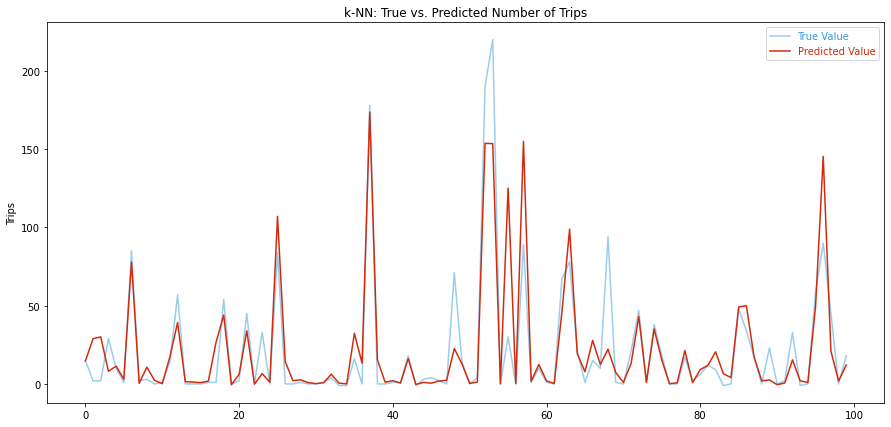

In [25]:
# Daily - prec=5
aggr_freq='D'
prec=5
model, X_train, X_test, y_train, y_test, trips_cnt_avg, trips_cnt_std, predictions = train_knn(aggr_freq=aggr_freq, precision=prec)
y_test_orig = (y_test * trips_cnt_std) + trips_cnt_avg
predictions = (predictions.flatten() * trips_cnt_std[0]) + trips_cnt_avg[0]
metrics_D_prec5 = evaluation_metrics(y_test_orig, predictions)
pred_vs_true(y_test_orig, predictions)

In [32]:
print('MAPE:\nPrecision=5\n\n', 
    'Temporal aggregation = 8h: ', metrics_8h_prec5['MAPE'], '\n', 
    'Temporal aggregation = 4h: ', metrics_4h_prec5['MAPE'], '\n', 
    'Temporal aggregation = h: ', metrics_h_prec5['MAPE'], '\n', 
    'Temporal aggregation = daily: ', metrics_D_prec5['MAPE'], '\n')

print('MAE:')
print('8H:', metrics_8h_prec5['MAE'], '\n4H:',  metrics_4h_prec5['MAE'], '\nH:', metrics_h_prec5['MAE'], '\nD:', metrics_D_prec5['MAE'])

MAPE:
Precision=5

 Temporal aggregation = 8h:  1754253264807879.5 
 Temporal aggregation = 4h:  749956347343065.5 
 Temporal aggregation = h:  257214030942534.3 
 Temporal aggregation = daily:  4297735785594635.0 

MAE:
8H: 4.158314196190823 
4H: 2.2797418745469558 
H: 0.5196691863001711 
D: 9.978652371945431


In [35]:
print('Best models with precision = 5:')
print('4H - prec=5', '\nMAE:', metrics_4h_prec5['MAE'], '\nMSE:', metrics_4h_prec5['MSE'], '\nR-squared:', metrics_4h_prec5['R-Squared'])
print('\n')
print('Hourly - prec=5', '\nMAE:', metrics_h_prec5['MAE'], '\nMSE:', metrics_h_prec5['MSE'], '\nR-squared:', metrics_h_prec5['R-Squared'])

Best models with precision = 5:
4H - prec=5 
MAE: 2.2797418745469558 
MSE: 28.29292255820667 
R-squared: 0.7255039016970755


Hourly - prec=5 
MAE: 0.5196691863001711 
MSE: 1.6479345355572406 
R-squared: 0.8076032344203459


daily: 80.7% of the variance explained

#### precision = 6

In [ ]:
# Daily - prec=6
aggr_freq='D'
prec=6
model, X_train, X_test, y_train, y_test, trips_cnt_avg, trips_cnt_std, predictions = train_knn(aggr_freq=aggr_freq, precision=prec)
y_test_orig = (y_test * trips_cnt_std) + trips_cnt_avg
predictions = (predictions.flatten() * trips_cnt_std[0]) + trips_cnt_avg[0]
metrics_D_prec6 = evaluation_metrics(y_test_orig, predictions)
pred_vs_true(y_test_orig, predictions)

In [ ]:
# 8h - prec=6
aggr_freq='8H'
prec=6
model, X_train, X_test, y_train, y_test, trips_cnt_avg, trips_cnt_std, predictions = train_knn(aggr_freq=aggr_freq, precision=prec)
y_test = (y_test * trips_cnt_std) + trips_cnt_avg
predictions = (predictions.flatten() * trips_cnt_std[0]) + trips_cnt_avg[0]
metrics_8h_prec6 = evaluation_metrics(y_test, predictions)
pred_vs_true(y_test, predictions)

In [ ]:
# 4h - prec=6
aggr_freq='4H'
prec=6
model, X_train, X_test, y_train, y_test, trips_cnt_avg, trips_cnt_std, predictions = train_knn(aggr_freq=aggr_freq, precision=prec)
y_test = (y_test * trips_cnt_std) + trips_cnt_avg
predictions = (predictions.flatten() * trips_cnt_std[0]) + trips_cnt_avg[0]
metrics_4h_prec6 = evaluation_metrics(y_test, predictions)
pred_vs_true(y_test, predictions)

In [ ]:
# h - prec=6
aggr_freq='H'
prec=6
model, X_train, X_test, y_train, y_test, trips_cnt_avg, trips_cnt_std, predictions = train_knn(aggr_freq=aggr_freq, precision=prec)
y_test = (y_test * trips_cnt_std) + trips_cnt_avg
predictions = (predictions.flatten() * trips_cnt_std[0]) + trips_cnt_avg[0]
metrics_h_prec6 = evaluation_metrics(y_test, predictions)
pred_vs_true(y_test, predictions)

In [ ]:
print('MAPE:\nPrecision=6\n\n', 
    'Temporal aggregation = 8h: ', metrics_8h_prec6['MAPE'], '\n', 
    'Temporal aggregation = 4h: ', metrics_4h_prec6['MAPE'], '\n', 
    'Temporal aggregation = h: ', metrics_h_prec6['MAPE'], '\n', 
    'Temporal aggregation = daily: ', metrics_D_prec6['MAPE'], '\n')

min(metrics_D_prec6['MAPE'], metrics_8h_prec6['MAPE'], metrics_4h_prec6['MAPE'], metrics_h_prec6['MAPE'])

In [ ]:
metrics_4h_prec6['MAE'], metrics_8h_prec6['MAE'], metrics_D_prec6['MAE'], metrics_h_prec6['MAE']

In [ ]:
print('Temporal aggregation = 4 hour.\nSpatial aggregation:\nprecision=5: MAE', metrics_4h_prec5['MAE'], '\nprecision=6: MAE', metrics_4h_prec6['MAE'])

In [ ]:
print('MAPE: \nprecision=5', metrics_4h_prec5['MAPE'], '\nprecision=6', metrics_4h_prec6['MAPE'])